In [1]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

In [2]:
import os
from pathlib import Path


# Sumber utama dataset CASME
BASE_CASME_DATASET_PATH = os.path.join(Path.home(), "datasets", "secondaries", "casme-2")

# Memastikan direktori dataset CASME ada
assert os.path.exists(BASE_CASME_DATASET_PATH), f"Dataset CASME tidak ditemukan di {BASE_CASME_DATASET_PATH}"

# Memastikan anotasi CASME ada
ANNOTATIONS_CASME_PATH = os.path.join(BASE_CASME_DATASET_PATH, "annotations.xlsx")

# Memastikan file anotasi CASME ada
assert os.path.exists(ANNOTATIONS_CASME_PATH), f"Anotasi CASME tidak ditemukan di {ANNOTATIONS_CASME_PATH}"

print("Datasource set successfully.")

Datasource set successfully.


In [3]:
import os
import glob


# Mendefinisikan path untuk cerita temporal subject 001
SUB_001_EP02_01F = os.path.join(BASE_CASME_DATASET_PATH, "sub01", "EP02_01f")

# Mendapatkan semua file dalam cerita temporal 006_1_2
SUB_001_EP02_FILES = glob.glob(os.path.join(SUB_001_EP02_01F, "*"))

# Mendefinisikan path untuk cerita temporal 006_1_3
SUB_001_EP03_02 = os.path.join(BASE_CASME_DATASET_PATH, "sub01", "EP03_02")

# Mendapatkan semua file dalam cerita temporal 006_1_3
SUB_001_EP03_FILES = glob.glob(os.path.join(SUB_001_EP03_02, "*"))

# Memastikan ada file yang ditemukan dalam cerita temporal 006_1_2
assert len(SUB_001_EP02_FILES) > 0, f"Tidak ada file ditemukan di {SUB_001_EP02_01F}"

assert len(SUB_001_EP03_FILES) > 0, f"Tidak ada file ditemukan di {SUB_001_EP03_02}"

print("Temporal sample files found successfully.")

Temporal sample files found successfully.


/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/_core/getlimits.py:558: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/_core/getlimits.py:90: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/_core/getlimits.py:558: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/_core/getlimits.py:90: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
W0000 00:00:1771075586.978

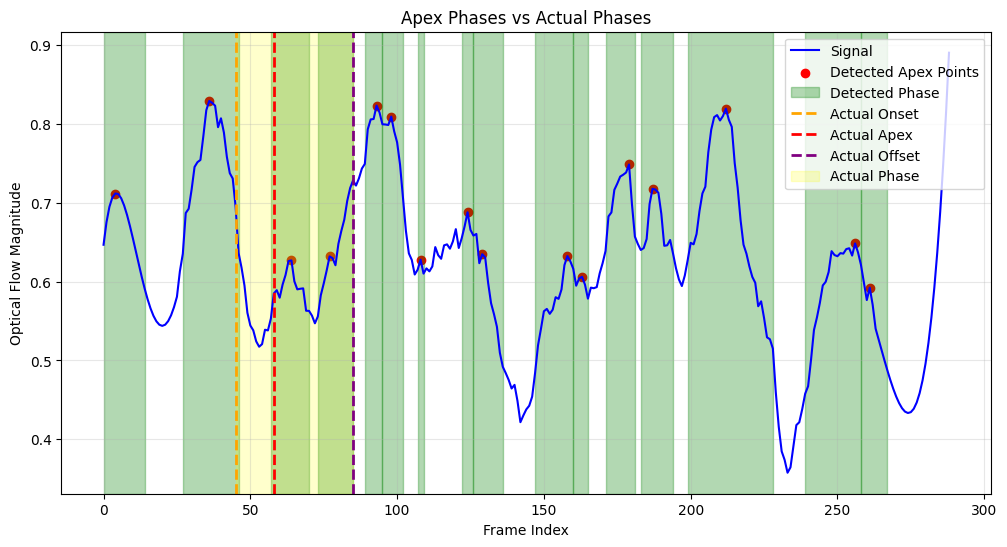

In [4]:
import cv2
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


magnitudes = []

face_landmark = FaceLandmark()

tvl1 = TVL1(fast_mode=True)

face_size = (240, 240)

for i in range(len(SUB_001_EP02_FILES) - 1):
    
    prev_frame = cv2.imread(SUB_001_EP02_FILES[i])
    next_frame = cv2.imread(SUB_001_EP02_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    prev_face = face_landmark.crop(image=prev_frame,
                                   landmarks=prev_landmarks,
                                   margin=0.05,
                                   output_size=face_size)

    next_face = face_landmark.crop(image=next_frame,
                                   landmarks=next_landmarks,
                                   margin=0.05,
                                   output_size=face_size)

    flow = tvl1.compute(prev_face, next_face, download=False)

    flow = flow.download()

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=45, apex=58, offset=85)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)

W0000 00:00:1771075697.644805   40717 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1771075697.650785   40719 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771075697.664076   40718 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


use cuda True


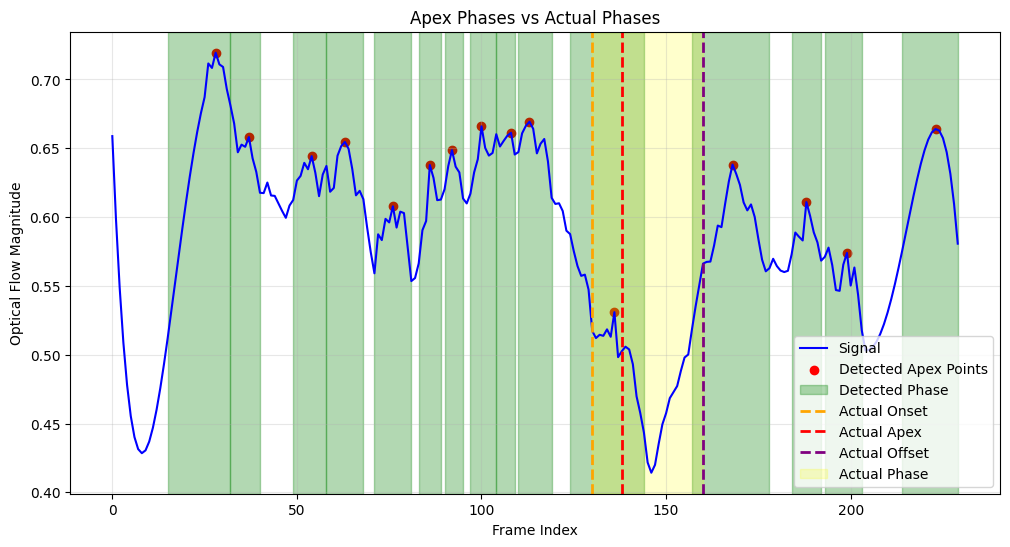

In [7]:
import cv2
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1


magnitudes = []

face_landmark = FaceLandmark()

tvl1 = TVL1()

face_size = (240, 240)

for i in range(len(SUB_001_EP03_FILES) - 1):
    
    prev_frame = cv2.imread(SUB_001_EP03_FILES[i])
    next_frame = cv2.imread(SUB_001_EP03_FILES[i + 1])

    prev_landmarks = face_landmark.detect(prev_frame)
    next_landmarks = face_landmark.detect(next_frame)

    prev_face = face_landmark.crop(image=prev_frame,
                                   landmarks=prev_landmarks,
                                   margin=0.05,
                                   output_size=face_size)

    next_face = face_landmark.crop(image=next_frame,
                                   landmarks=next_landmarks,
                                   margin=0.05,
                                   output_size=face_size)

    flow = tvl1.compute(prev_face, next_face, download=False)

    flow = flow.download()

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=130, apex=138, offset=160)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smoothed_magnitudes, 
                                              apex_indices=apexs, 
                                              phases=phases,
                                              actual_phases=actual_phases)

Menghitung nilai magnitudo berdasarkan region of interests

W0000 00:00:1771078046.810609   47155 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1771078046.815407   47159 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771078046.830123   47172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


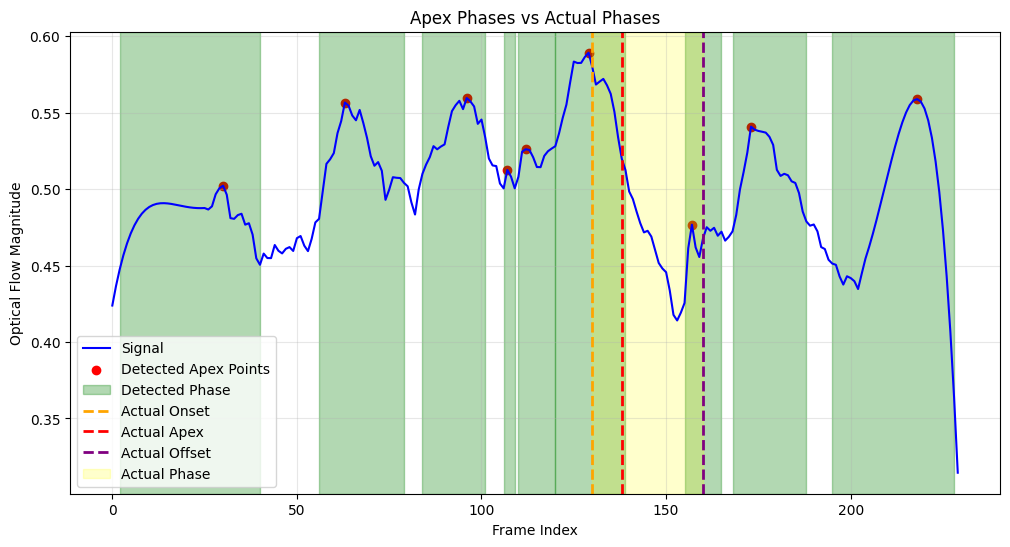

In [16]:
# ...existing code...
import cv2
import math
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark, FaceRoiPoints
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1

face_landmark = FaceLandmark()
tvl1 = TVL1(fast_mode=True)

roi_defs = [
    frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
    frozenset(FaceRoiPoints.LIPS_POINTS),
    frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS),
]

def extract_magnitudes_roi_canvas(frame_files, tile_size=(64, 64), cols=3, margin=0.05):
    magnitudes = []

    tile_w, tile_h = tile_size
    rows = math.ceil(len(roi_defs) / cols)

    for i in range(len(frame_files) - 1):
        prev_frame = cv2.imread(frame_files[i])
        next_frame = cv2.imread(frame_files[i + 1])

        if prev_frame is None or next_frame is None:
            continue

        prev_landmarks = face_landmark.detect(prev_frame)
        next_landmarks = face_landmark.detect(next_frame)

        canvas_prev = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
        canvas_next = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
        canvas_mask = np.zeros((rows * tile_h, cols * tile_w), dtype=np.uint8)

        for j, roi_points in enumerate(roi_defs):
            roi_prev, mask_prev = face_landmark.crop_roi(
                image=prev_frame,
                landmark_result=prev_landmarks,
                roi_points=roi_points,
                margin=margin,
                target_size=tile_size
            )
            roi_next, mask_next = face_landmark.crop_roi(
                image=next_frame,
                landmark_result=next_landmarks,  # penting: next_landmarks
                roi_points=roi_points,
                margin=margin,
                target_size=tile_size
            )

            r, c = divmod(j, cols)
            y1, y2 = r * tile_h, (r + 1) * tile_h
            x1, x2 = c * tile_w, (c + 1) * tile_w

            canvas_prev[y1:y2, x1:x2] = roi_prev
            canvas_next[y1:y2, x1:x2] = roi_next
            canvas_mask[y1:y2, x1:x2] = ((mask_prev > 0) & (mask_next > 0)).astype(np.uint8)

        flow = tvl1.compute(canvas_prev, canvas_next, download=False)
        if hasattr(flow, "download"):  # CUDA path
            flow = flow.download()

        magnitude = np.hypot(flow[..., 0], flow[..., 1])
        valid = canvas_mask > 0
        mean_magnitude = float(np.mean(magnitude[valid])) if np.any(valid) else float(np.mean(magnitude))
        magnitudes.append(mean_magnitude)

    return magnitudes

# contoh pakai untuk EP03
magnitudes = extract_magnitudes_roi_canvas(SUB_001_EP03_FILES, tile_size=(64, 64), cols=3, margin=0.05)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))
polyorder = ApexSmoother.calculate_polyorder(window_length)
smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()
apexs = apex_phase.find_apex(signal=smoothed_magnitudes)
phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=130, apex=138, offset=160)
ApexPhaseVisualizer().plot_phases_with_actual(signal=smoothed_magnitudes,
                                              apex_indices=apexs,
                                              phases=phases,
                                              actual_phases=actual_phases)

W0000 00:00:1771077978.397181   47113 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1771077978.402645   47118 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771077978.414220   47127 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


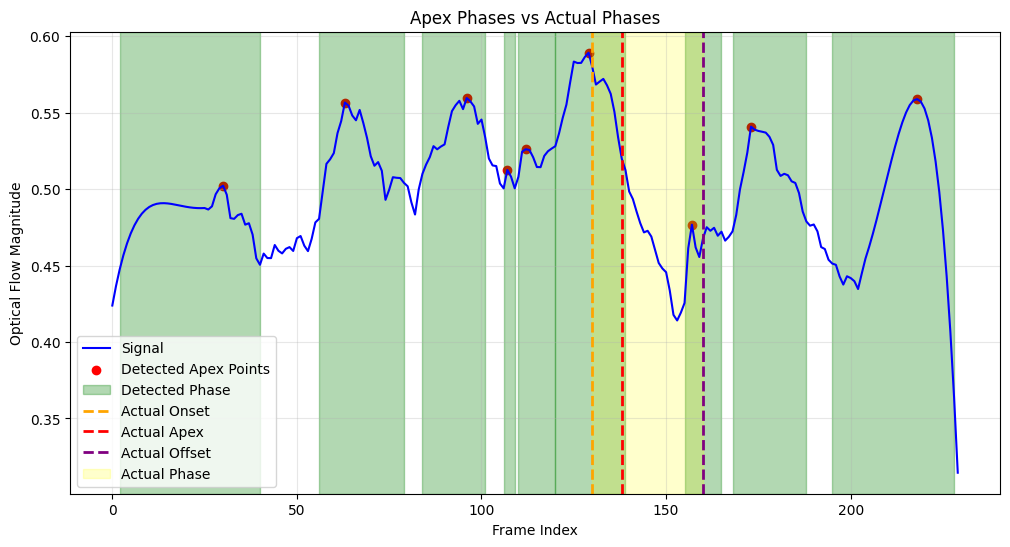

In [15]:
import cv2
import math
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark, FaceRoiPoints
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1

face_landmark = FaceLandmark()
tvl1 = TVL1(fast_mode=True)

roi_defs = [
    frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
    frozenset(FaceRoiPoints.LIPS_POINTS),
    frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS),
]

def extract_magnitudes_roi_canvas(frame_files, tile_size=(64, 64), cols=3, margin=0.05):
    magnitudes = []

    tile_w, tile_h = tile_size
    rows = math.ceil(len(roi_defs) / cols)

    for i in range(len(frame_files) - 1):
        prev_frame = cv2.imread(frame_files[i])
        next_frame = cv2.imread(frame_files[i + 1])

        if prev_frame is None or next_frame is None:
            continue

        prev_landmarks = face_landmark.detect(prev_frame)
        next_landmarks = face_landmark.detect(next_frame)

        canvas_prev = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
        canvas_next = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
        canvas_mask = np.zeros((rows * tile_h, cols * tile_w), dtype=np.uint8)

        for j, roi_points in enumerate(roi_defs):
            roi_prev, mask_prev = face_landmark.crop_roi(image=prev_frame,
                                                         landmark_result=prev_landmarks,
                                                         roi_points=roi_points,
                                                         margin=margin,
                                                         target_size=tile_size)
            
            roi_next, mask_next = face_landmark.crop_roi(image=next_frame,
                                                         landmark_result=next_landmarks,
                                                         roi_points=roi_points,
                                                         margin=margin,
                                                         target_size=tile_size)

            r, c = divmod(j, cols)
            y1, y2 = r * tile_h, (r + 1) * tile_h
            x1, x2 = c * tile_w, (c + 1) * tile_w

            canvas_prev[y1:y2, x1:x2] = roi_prev
            canvas_next[y1:y2, x1:x2] = roi_next
            canvas_mask[y1:y2, x1:x2] = ((mask_prev > 0) & (mask_next > 0)).astype(np.uint8)

        flow = tvl1.compute(canvas_prev, canvas_next, download=False)
        if hasattr(flow, "download"):
            flow = flow.download()

        magnitude = np.hypot(flow[..., 0], flow[..., 1])
        valid = canvas_mask > 0
        mean_magnitude = float(np.mean(magnitude[valid])) if np.any(valid) else float(np.mean(magnitude))
        magnitudes.append(mean_magnitude)

    return magnitudes


magnitudes = extract_magnitudes_roi_canvas(SUB_001_EP03_FILES, tile_size=(64, 64), cols=3, margin=0.05)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)

phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=130, apex=138, offset=160)

ApexPhaseVisualizer().plot_phases_with_actual(signal=smoothed_magnitudes,
                                              apex_indices=apexs,
                                              phases=phases,
                                              actual_phases=actual_phases)

In [10]:
import os
import glob


# Mendefinisikan path untuk cerita temporal 006_1_3
SUB_001_EP04_02 = os.path.join(BASE_CASME_DATASET_PATH, "sub01", "EP04_02")

# Mendapatkan semua file dalam cerita temporal 006_1_3
SUB_001_EP04_FILES = glob.glob(os.path.join(SUB_001_EP04_02, "*"))

W0000 00:00:1771077070.744253   43413 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1771077070.748696   43414 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771077070.760627   43414 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


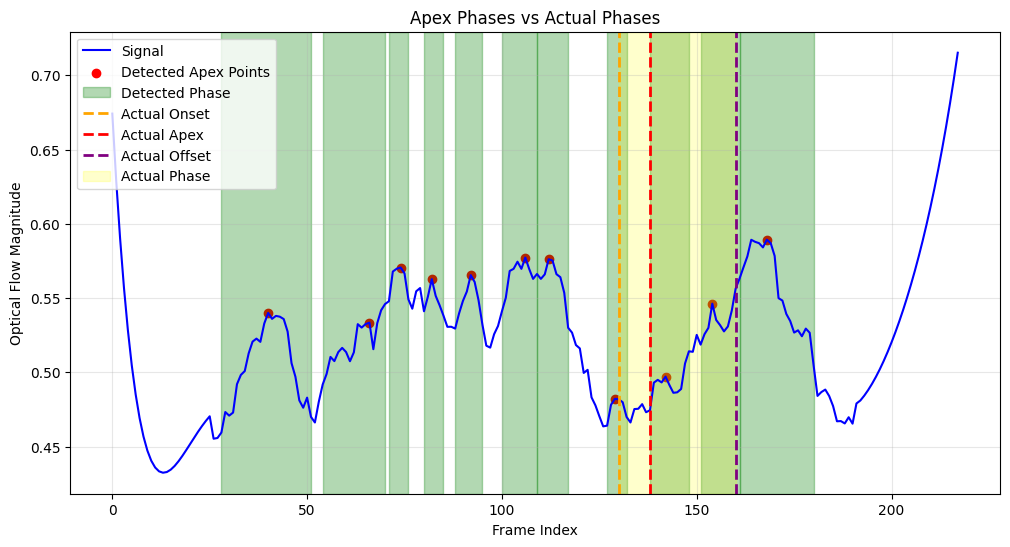

In [ ]:
import cv2
import math
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark, FaceRoiPoints
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer
from src.optical_flow.modules import TVL1

face_landmark = FaceLandmark()
tvl1 = TVL1(fast_mode=True)

roi_defs = [
    frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
    frozenset(FaceRoiPoints.LIPS_POINTS),
    frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS),
]

def extract_magnitudes_roi_canvas(frame_files, tile_size=(64, 64), cols=3, margin=0.05):
    magnitudes = []

    tile_w, tile_h = tile_size
    rows = math.ceil(len(roi_defs) / cols)

    for i in range(len(frame_files) - 1):
        prev_frame = cv2.imread(frame_files[i])
        next_frame = cv2.imread(frame_files[i + 1])

        if prev_frame is None or next_frame is None:
            continue

        prev_landmarks = face_landmark.detect(prev_frame)
        next_landmarks = face_landmark.detect(next_frame)

        canvas_prev = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
        canvas_next = np.zeros((rows * tile_h, cols * tile_w, 3), dtype=np.uint8)
        canvas_mask = np.zeros((rows * tile_h, cols * tile_w), dtype=np.uint8)

        for j, roi_points in enumerate(roi_defs):
            roi_prev, mask_prev = face_landmark.crop_roi(image=prev_frame,
                                                         landmark_result=prev_landmarks,
                                                         roi_points=roi_points,
                                                         margin=margin,
                                                         target_size=tile_size)
            
            roi_next, mask_next = face_landmark.crop_roi(image=next_frame,
                                                         landmark_result=next_landmarks,
                                                         roi_points=roi_points,
                                                         margin=margin,
                                                         target_size=tile_size)

            r, c = divmod(j, cols)
            y1, y2 = r * tile_h, (r + 1) * tile_h
            x1, x2 = c * tile_w, (c + 1) * tile_w

            canvas_prev[y1:y2, x1:x2] = roi_prev
            canvas_next[y1:y2, x1:x2] = roi_next
            canvas_mask[y1:y2, x1:x2] = ((mask_prev > 0) & (mask_next > 0)).astype(np.uint8)

        flow = tvl1.compute(canvas_prev, canvas_next, download=False)
        if hasattr(flow, "download"):
            flow = flow.download()

        magnitude = np.hypot(flow[..., 0], flow[..., 1])
        valid = canvas_mask > 0
        mean_magnitude = float(np.mean(magnitude[valid])) if np.any(valid) else float(np.mean(magnitude))
        magnitudes.append(mean_magnitude)

    return magnitudes


magnitudes = extract_magnitudes_roi_canvas(SUB_001_EP04_FILES, tile_size=(64, 64), cols=3, margin=0.05)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_phase = ApexPhase()

apexs = apex_phase.find_apex(signal=smoothed_magnitudes)

phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apexs)

actual_phases = dict(onset=130, apex=138, offset=160)

ApexPhaseVisualizer().plot_phases_with_actual(signal=smoothed_magnitudes,
                                              apex_indices=apexs,
                                              phases=phases,
                                              actual_phases=actual_phases)